In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Assuming the file is in the root of MyDrive. Adjust the path if needed.
df = pd.read_csv('/content/drive/MyDrive/student_performance.csv')

print('=== Dataset Loaded Successfully ===')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
print('=== First 5 Rows ===')
df.head()

=== Dataset Loaded Successfully ===
Shape: 30 rows x 13 columns

=== First 5 Rows ===


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [6]:
print('=== Column Names ===')
print(df.columns.tolist())
print()
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values Per Column ===')
print(df.isnull().sum())
print()
print(f'=== Duplicate Records: {df.duplicated().sum()} ===')
print()
print('=== Statistical Summary ===')
df.describe()

=== Column Names ===
['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

=== Data Types ===
student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object

=== Missing Values Per Column ===
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city       

,student_id,age,semester,math_score,science_score,english_score,programming_score,attendance_percentage,admission_year
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.0
mean,1015.500000,19.733333,2.0,76.066667,77.833333,74.166667,67.600000,84.500000,2023.0
std,8.803408,0.739680,0.0,11.467896,8.554423,10.003735,21.041175,9.379913,0.0
min,1001.000000,19.000000,2.0,56.000000,61.000000,55.000000,38.000000,65.000000,2023.0
25%,1008.250000,19.000000,2.0,67.250000,71.250000,67.250000,49.250000,77.250000,2023.0
50%,1015.500000,20.000000,2.0,75.500000,78.000000,75.000000,66.000000,86.500000,2023.0
75%,1022.750000,20.000000,2.0,85.750000,83.750000,81.750000,88.750000,91.750000,2023.0
max,1030.000000,21.000000,2.0,95.000000,93.000000,90.000000,97.000000,98.000000,2023.0


In [7]:
df_clean = df.copy()


num_cols = ['math_score', 'science_score', 'english_score',
            'programming_score', 'attendance_percentage']
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in ['department', 'gender', 'city']:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [8]:

before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_clean)}')


df_clean['attendance_percentage'] = df_clean['attendance_percentage'].astype(float)
for col in ['math_score','science_score','english_score','programming_score']:
    df_clean[col] = df_clean[col].astype(int)

df_clean.rename(columns={
    'math_score'            : 'Math_Score',
    'science_score'         : 'Science_Score',
    'english_score'         : 'English_Score',
    'programming_score'     : 'Programming_Score',
    'attendance_percentage' : 'Attendance_Pct',
    'admission_year'        : 'Admission_Year'
}, inplace=True)

print('Cleaned shape:', df_clean.shape)
print('Columns:', df_clean.columns.tolist())
df_clean.head()

Duplicates removed: 0
Cleaned shape: (30, 13)
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'Math_Score', 'Science_Score', 'English_Score', 'Programming_Score', 'Attendance_Pct', 'city', 'Admission_Year']


,student_id,name,age,gender,department,semester,Math_Score,Science_Score,English_Score,Programming_Score,Attendance_Pct,city,Admission_Year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92.0,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87.0,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78.0,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95.0,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90.0,Kochi,2023


In [9]:
df_clean.to_csv('student_performance_cleaned.csv', index=False)
print('Cleaned dataset saved as student_performance_cleaned.csv')

Cleaned dataset saved as student_performance_cleaned.csv


In [10]:
import sqlite3

conn   = sqlite3.connect('student_performance.db')
cursor = conn.cursor()

df_clean.to_sql('students', conn, if_exists='replace', index=False)

cursor.execute('SELECT COUNT(*) FROM students')
print(f'Records inserted into SQLite: {cursor.fetchone()[0]}')

cursor.execute('PRAGMA table_info(students)')
print('\nTable schema:')
for col in cursor.fetchall():
    print(f'  {col[1]} ({col[2]})')

Records inserted into SQLite: 30

Table schema:
  student_id (INTEGER)
  name (TEXT)
  age (INTEGER)
  gender (TEXT)
  department (TEXT)
  semester (INTEGER)
  Math_Score (INTEGER)
  Science_Score (INTEGER)
  English_Score (INTEGER)
  Programming_Score (INTEGER)
  Attendance_Pct (REAL)
  city (TEXT)
  Admission_Year (INTEGER)


In [11]:

q1 = '''
    SELECT name, department, Programming_Score, Attendance_Pct
    FROM students
    WHERE Attendance_Pct >= 90
      AND Programming_Score > 80
    ORDER BY Programming_Score DESC
'''
print('Query 1 — FILTERING: High attendance AND high Programming Score')
print(pd.read_sql_query(q1, conn).to_string(index=False))

Query 1 — FILTERING: High attendance AND high Programming Score
          name       department  Programming_Score  Attendance_Pct
    Ananya Das Computer Science                 97            98.0
   Tanvi Mehta Computer Science                 96            97.0
    Arjun Nair Computer Science                 95            90.0
Akanksha Yadav Computer Science                 94            95.0
   Divya Singh Computer Science                 93            96.0
Swati Kulkarni Computer Science                 92            94.0
  Aarav Sharma Computer Science                 91            92.0
     Amit Bose Computer Science                 89            91.0


In [12]:

q2 = '''
    SELECT name, department, gender,
           (Math_Score + Science_Score + English_Score + Programming_Score) AS Total_Score
    FROM students
    ORDER BY Total_Score DESC
    LIMIT 10
'''
print('Query 2 — SORTING: Top 10 students by Total Score')
print(pd.read_sql_query(q2, conn).to_string(index=False))

Query 2 — SORTING: Top 10 students by Total Score
          name       department gender  Total_Score
    Ananya Das Computer Science Female          371
   Tanvi Mehta Computer Science Female          367
Akanksha Yadav Computer Science Female          365
    Arjun Nair Computer Science   Male          356
   Divya Singh Computer Science Female          356
Swati Kulkarni Computer Science Female          354
     Amit Bose Computer Science   Male          336
    Suresh Rao Computer Science   Male          334
  Nisha Kapoor Computer Science Female          327
  Aarav Sharma Computer Science   Male          326


In [13]:

q3 = '''
    SELECT
        COUNT(*)                                                               AS Total_Students,
        ROUND(AVG(Math_Score), 2)                                              AS Avg_Math,
        ROUND(AVG(Science_Score), 2)                                           AS Avg_Science,
        ROUND(AVG(English_Score), 2)                                           AS Avg_English,
        ROUND(AVG(Programming_Score), 2)                                       AS Avg_Programming,
        ROUND(AVG(Attendance_Pct), 2)                                          AS Avg_Attendance,
        ROUND(AVG(Math_Score + Science_Score + English_Score + Programming_Score), 2) AS Avg_Total
    FROM students
'''
print('Query 3 — AGGREGATION: Overall Performance Metrics')
print(pd.read_sql_query(q3, conn).T.rename(columns={0:'Value'}))

Query 3 — AGGREGATION: Overall Performance Metrics
                  Value
Total_Students    30.00
Avg_Math          76.07
Avg_Science       77.83
Avg_English       74.17
Avg_Programming   67.60
Avg_Attendance    84.50
Avg_Total        295.67


In [14]:

q4 = '''
    SELECT department,
           COUNT(*)                         AS Student_Count,
           ROUND(AVG(Math_Score), 2)        AS Avg_Math,
           ROUND(AVG(Science_Score), 2)     AS Avg_Science,
           ROUND(AVG(English_Score), 2)     AS Avg_English,
           ROUND(AVG(Programming_Score), 2) AS Avg_Programming,
           ROUND(AVG(Attendance_Pct), 2)    AS Avg_Attendance
    FROM students
    GROUP BY department
    ORDER BY Avg_Programming DESC
'''
print('Query 4 — GROUP BY: Performance by Department')
print(pd.read_sql_query(q4, conn).to_string(index=False))

Query 4 — GROUP BY: Performance by Department
      department  Student_Count  Avg_Math  Avg_Science  Avg_English  Avg_Programming  Avg_Attendance
Computer Science             13     85.62        84.46        80.85            89.23           90.69
     Electronics              6     71.00        74.17        70.83            61.50           80.33
      Mechanical              6     71.00        76.50        70.50            49.33           83.50
           Civil              5     63.40        66.60        65.20            40.60           74.60


In [15]:

q5 = '''
    SELECT name, department, gender,
           Math_Score, Science_Score, English_Score, Programming_Score
    FROM students
    WHERE Math_Score        > (SELECT AVG(Math_Score)        FROM students)
      AND Science_Score     > (SELECT AVG(Science_Score)     FROM students)
      AND English_Score     > (SELECT AVG(English_Score)     FROM students)
      AND Programming_Score > (SELECT AVG(Programming_Score) FROM students)
    ORDER BY (Math_Score + Science_Score + English_Score + Programming_Score) DESC
'''
print('Query 5 — CONDITIONAL: Students above average in ALL 4 subjects')
print(pd.read_sql_query(q5, conn).to_string(index=False))

Query 5 — CONDITIONAL: Students above average in ALL 4 subjects
          name       department gender  Math_Score  Science_Score  English_Score  Programming_Score
    Ananya Das Computer Science Female          95             89             90                 97
   Tanvi Mehta Computer Science Female          93             90             88                 96
Akanksha Yadav Computer Science Female          91             93             87                 94
    Arjun Nair Computer Science   Male          92             88             81                 95
   Divya Singh Computer Science Female          88             91             84                 93
Swati Kulkarni Computer Science Female          90             87             85                 92
     Amit Bose Computer Science   Male          86             82             79                 89
    Suresh Rao Computer Science   Male          83             86             77                 88
  Nisha Kapoor Computer Science Fema

In [16]:
q_transform = '''
    SELECT *,
        CASE
            WHEN (Math_Score + Science_Score + English_Score + Programming_Score) >= 320 THEN 'Distinction'
            WHEN (Math_Score + Science_Score + English_Score + Programming_Score) >= 260 THEN 'First Class'
            WHEN (Math_Score + Science_Score + English_Score + Programming_Score) >= 200 THEN 'Second Class'
            ELSE 'Pass'
        END AS Grade_Category,
        CASE
            WHEN Attendance_Pct >= 90 THEN 'Excellent'
            WHEN Attendance_Pct >= 75 THEN 'Regular'
            ELSE 'Low Attendance'
        END AS Attendance_Status
    FROM students
'''
df_transformed = pd.read_sql_query(q_transform, conn)

print('New derived columns: Grade_Category, Attendance_Status')
print(df_transformed[['name','department','Math_Score','Science_Score',
                       'English_Score','Programming_Score',
                       'Grade_Category','Attendance_Pct','Attendance_Status']].to_string(index=False))

df_transformed.to_csv('student_transformed.csv', index=False)
print('\nSaved as student_transformed.csv')

New derived columns: Grade_Category, Attendance_Status
          name       department  Math_Score  Science_Score  English_Score  Programming_Score Grade_Category  Attendance_Pct Attendance_Status
  Aarav Sharma Computer Science          85             78             72                 91    Distinction            92.0         Excellent
   Priya Patel Computer Science          76             82             88                 79    Distinction            87.0           Regular
   Rohit Verma      Electronics          65             74             61                 55   Second Class            78.0           Regular
   Sneha Reddy       Mechanical          70             80             75                 48    First Class            95.0         Excellent
    Arjun Nair Computer Science          92             88             81                 95    Distinction            90.0         Excellent
   Meera Joshi      Electronics          58             66             70                 52 

In [18]:
import pandas as pd
import numpy as np

def etl_extract(filepath):
    print('[EXTRACT] Reading from:', filepath)
    df = pd.read_csv(filepath)
    print(f'[EXTRACT] Loaded {df.shape[0]} rows x {df.shape[1]} columns.')
    return df

def etl_transform(df):
    print('\n[TRANSFORM] Starting...')
    df = df.copy()


    for col in ['math_score','science_score','english_score','programming_score','attendance_percentage']:
        df[col].fillna(df[col].median(), inplace=True)
    for col in ['department','gender','city']:
        df[col].fillna(df[col].mode()[0], inplace=True)


    df.drop_duplicates(inplace=True)


    df['Total_Score']   = df['math_score'] + df['science_score'] + df['english_score'] + df['programming_score']
    df['Average_Score'] = (df['Total_Score'] / 4).round(2)

    df['Grade'] = pd.cut(
        df['Total_Score'],
        bins=[0, 199, 259, 319, 400],
        labels=['Pass', 'Second Class', 'First Class', 'Distinction']
    )

    df['Attendance_Status'] = df['attendance_percentage'].apply(
        lambda x: 'Excellent' if x >= 90 else ('Regular' if x >= 75 else 'Low Attendance')
    )

    df['Is_Top_Performer'] = (df['Total_Score'] >= df['Total_Score'].quantile(0.75)).astype(int)

    print('[TRANSFORM] New columns: Total_Score, Average_Score, Grade, Attendance_Status, Is_Top_Performer')
    print('[TRANSFORM] Shape after transform:', df.shape)
    return df

def etl_load(df, output_path):
    df.to_csv(output_path, index=False)
    print(f'\n[LOAD] Saved to {output_path} — {df.shape[0]} rows x {df.shape[1]} columns')

print('===== ETL PIPELINE START =====')
raw_df   = etl_extract('/content/drive/MyDrive/student_performance.csv')
clean_df = etl_transform(raw_df)
etl_load(clean_df, 'student_etl_output.csv')
print('===== ETL PIPELINE COMPLETE =====')

===== ETL PIPELINE START =====
[EXTRACT] Reading from: /content/drive/MyDrive/student_performance.csv
[EXTRACT] Loaded 30 rows x 13 columns.

[TRANSFORM] Starting...
[TRANSFORM] New columns: Total_Score, Average_Score, Grade, Attendance_Status, Is_Top_Performer
[TRANSFORM] Shape after transform: (30, 18)

[LOAD] Saved to student_etl_output.csv — 30 rows x 18 columns
===== ETL PIPELINE COMPLETE =====


In [19]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os

spark = SparkSession.builder \
    .appName('Codeboosters_StudentMedallion') \
    .master('local[*]') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('Spark Session started.')

Spark Session started.


In [21]:

print('BRONZE LAYER')
bronze = spark.read.csv('/content/drive/MyDrive/student_performance.csv', header=True, inferSchema=True)
bronze.printSchema()
print('Bronze count:', bronze.count())
os.makedirs('medallion/bronze', exist_ok=True)
bronze.write.mode('overwrite').parquet('medallion/bronze/students_bronze.parquet')
print('Bronze saved.')

BRONZE LAYER
root
 |-- student_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- department: string (nullable = true)
 |-- semester: integer (nullable = true)
 |-- math_score: integer (nullable = true)
 |-- science_score: integer (nullable = true)
 |-- english_score: integer (nullable = true)
 |-- programming_score: integer (nullable = true)
 |-- attendance_percentage: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- admission_year: integer (nullable = true)

Bronze count: 30
Bronze saved.


In [22]:

print('SILVER LAYER')
silver = spark.read.parquet('medallion/bronze/students_bronze.parquet')

for col in ['math_score','science_score','english_score','programming_score','attendance_percentage']:
    med = silver.approxQuantile(col, [0.5], 0.01)[0]
    silver = silver.fillna({col: med})

silver = silver.dropDuplicates()

for c in silver.columns:
    silver = silver.withColumnRenamed(c, c.upper())

silver = silver.withColumn('TOTAL_SCORE',
    F.col('MATH_SCORE') + F.col('SCIENCE_SCORE') +
    F.col('ENGLISH_SCORE') + F.col('PROGRAMMING_SCORE'))

print('Silver count:', silver.count())
silver.show(5)
os.makedirs('medallion/silver', exist_ok=True)
silver.write.mode('overwrite').parquet('medallion/silver/students_silver.parquet')
print('Silver saved.')

SILVER LAYER
Silver count: 30
+----------+--------------+---+------+-----------+--------+----------+-------------+-------------+-----------------+---------------------+------------------+--------------+-----------+
|STUDENT_ID|          NAME|AGE|GENDER| DEPARTMENT|SEMESTER|MATH_SCORE|SCIENCE_SCORE|ENGLISH_SCORE|PROGRAMMING_SCORE|ATTENDANCE_PERCENTAGE|              CITY|ADMISSION_YEAR|TOTAL_SCORE|
+----------+--------------+---+------+-----------+--------+----------+-------------+-------------+-----------------+---------------------+------------------+--------------+-----------+
|      1028| Sunita Pillai| 19|Female|      Civil|       2|        60|           65|           68|               39|                   73|Thiruvananthapuram|          2023|        232|
|      1019|Deepak Chauhan| 20|  Male| Mechanical|       2|        68|           73|           62|               49|                   77|          Dehradun|          2023|        252|
|      1006|   Meera Joshi| 20|Female|Electro

In [23]:

print('GOLD LAYER')
gold = spark.read.parquet('medallion/silver/students_silver.parquet')

gold_dept = gold.groupBy('DEPARTMENT').agg(
    F.count('*').alias('Student_Count'),
    F.round(F.avg('MATH_SCORE'), 2).alias('Avg_Math'),
    F.round(F.avg('PROGRAMMING_SCORE'), 2).alias('Avg_Programming'),
    F.round(F.avg('TOTAL_SCORE'), 2).alias('Avg_Total'),
    F.round(F.avg('ATTENDANCE_PERCENTAGE'), 2).alias('Avg_Attendance')
).orderBy('Avg_Total', ascending=False)

gold_gender = gold.groupBy('GENDER').agg(
    F.count('*').alias('Count'),
    F.round(F.avg('TOTAL_SCORE'), 2).alias('Avg_Total'),
    F.round(F.avg('ATTENDANCE_PERCENTAGE'), 2).alias('Avg_Attendance')
)

print('KPI 1 — By Department:'); gold_dept.show()
print('KPI 2 — By Gender:'); gold_gender.show()

os.makedirs('medallion/gold', exist_ok=True)
gold_dept.write.mode('overwrite').parquet('medallion/gold/by_department.parquet')
gold_gender.write.mode('overwrite').parquet('medallion/gold/by_gender.parquet')
print('Gold saved.')

GOLD LAYER
KPI 1 — By Department:
+----------------+-------------+--------+---------------+---------+--------------+
|      DEPARTMENT|Student_Count|Avg_Math|Avg_Programming|Avg_Total|Avg_Attendance|
+----------------+-------------+--------+---------------+---------+--------------+
|Computer Science|           13|   85.62|          89.23|   340.15|         90.69|
|     Electronics|            6|    71.0|           61.5|    277.5|         80.33|
|      Mechanical|            6|    71.0|          49.33|   267.33|          83.5|
|           Civil|            5|    63.4|           40.6|    235.8|          74.6|
+----------------+-------------+--------+---------------+---------+--------------+

KPI 2 — By Gender:
+------+-----+---------+--------------+
|GENDER|Count|Avg_Total|Avg_Attendance|
+------+-----+---------+--------------+
|Female|   15|   310.67|         88.53|
|  Male|   15|   280.67|         80.47|
+------+-----+---------+--------------+

Gold saved.


In [24]:
import os, time, pandas as pd

csv_path     = 'student_performance_cleaned.csv'
parquet_path = 'student_performance_cleaned.parquet'

pd.read_csv(csv_path).to_parquet(parquet_path, index=False)

csv_size     = os.path.getsize(csv_path)
parquet_size = os.path.getsize(parquet_path)

start = time.time()
for _ in range(50): pd.read_csv(csv_path)
csv_ms = round((time.time()-start)/50*1000, 3)

start = time.time()
for _ in range(50): pd.read_parquet(parquet_path)
parquet_ms = round((time.time()-start)/50*1000, 3)

comparison = pd.DataFrame({
    'Dimension'  : ['File Size (bytes)','Storage Efficiency','Read Performance (avg)',
                    'Human Readable','Type Preservation','Compression','Best Use Case'],
    'CSV'        : [f'{csv_size:,}','Low — plain text',f'{csv_ms} ms',
                    'Yes','No — everything is string','None natively',
                    'Data sharing, small files, human review'],
    'Parquet'    : [f'{parquet_size:,}','High — columnar + compression',f'{parquet_ms} ms',
                    'No — binary','Yes — preserves all types','Snappy/GZIP built-in',
                    'Big data, Spark/Hive, cloud data lakes']
})
print(comparison.to_string(index=False))

             Dimension                                     CSV                                Parquet
     File Size (bytes)                                   2,296                                  9,424
    Storage Efficiency                        Low — plain text          High — columnar + compression
Read Performance (avg)                                2.272 ms                               5.382 ms
        Human Readable                                     Yes                            No — binary
     Type Preservation               No — everything is string              Yes — preserves all types
           Compression                           None natively                   Snappy/GZIP built-in
         Best Use Case Data sharing, small files, human review Big data, Spark/Hive, cloud data lakes


In [25]:
spark = SparkSession.builder.appName('ParquetToPandas').master('local[*]').getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

spark_df = spark.read.parquet('medallion/silver/students_silver.parquet')
print('PySpark schema:')
spark_df.printSchema()
print('Record count:', spark_df.count())

PySpark schema:
root
 |-- STUDENT_ID: integer (nullable = true)
 |-- NAME: string (nullable = true)
 |-- AGE: integer (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- DEPARTMENT: string (nullable = true)
 |-- SEMESTER: integer (nullable = true)
 |-- MATH_SCORE: integer (nullable = true)
 |-- SCIENCE_SCORE: integer (nullable = true)
 |-- ENGLISH_SCORE: integer (nullable = true)
 |-- PROGRAMMING_SCORE: integer (nullable = true)
 |-- ATTENDANCE_PERCENTAGE: integer (nullable = true)
 |-- CITY: string (nullable = true)
 |-- ADMISSION_YEAR: integer (nullable = true)
 |-- TOTAL_SCORE: integer (nullable = true)

Record count: 30


In [26]:
pandas_df = spark_df.toPandas()
print('Converted to Pandas successfully!')
print('Shape:', pandas_df.shape)
pandas_df.head()

Converted to Pandas successfully!
Shape: (30, 14)


,STUDENT_ID,NAME,AGE,GENDER,DEPARTMENT,SEMESTER,MATH_SCORE,SCIENCE_SCORE,ENGLISH_SCORE,PROGRAMMING_SCORE,ATTENDANCE_PERCENTAGE,CITY,ADMISSION_YEAR,TOTAL_SCORE
0,1028,Sunita Pillai,19,Female,Civil,2,60,65,68,39,73,Thiruvananthapuram,2023,232
1,1019,Deepak Chauhan,20,Male,Mechanical,2,68,73,62,49,77,Dehradun,2023,252
2,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023,246
3,1014,Kavya Nambiar,20,Female,Mechanical,2,74,78,82,51,91,Thrissur,2023,285
4,1016,Ritu Agarwal,20,Female,Electronics,2,87,83,86,69,93,Agra,2023,325


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
df_viz = pd.read_csv('student_etl_output.csv')

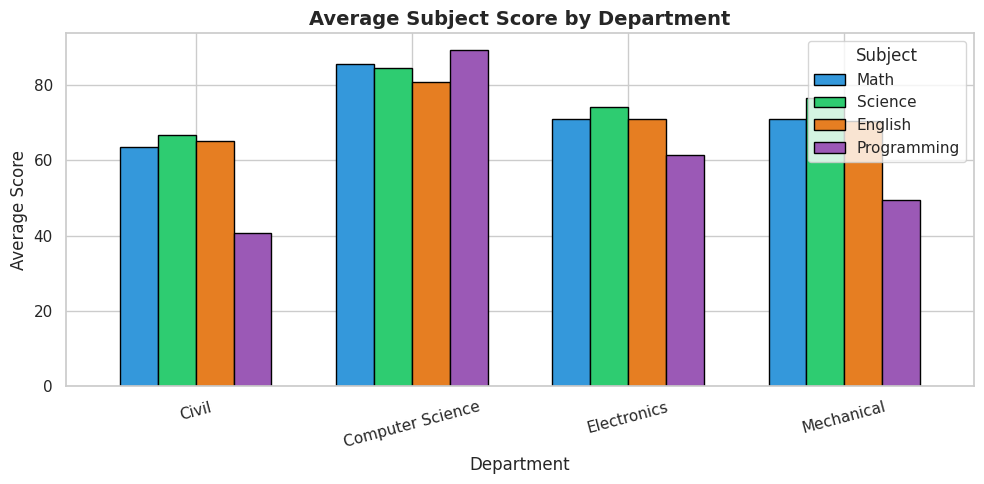

In [28]:

fig, ax = plt.subplots(figsize=(10, 5))
dept_scores = df_viz.groupby('department')[['math_score','science_score',
                                             'english_score','programming_score']].mean()
dept_scores.plot(kind='bar', ax=ax,
                 color=['#3498db','#2ecc71','#e67e22','#9b59b6'],
                 edgecolor='black', width=0.7)
ax.set_title('Average Subject Score by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Average Score')
ax.set_xticklabels(dept_scores.index, rotation=15)
ax.legend(['Math','Science','English','Programming'], title='Subject')
plt.tight_layout()
plt.show()

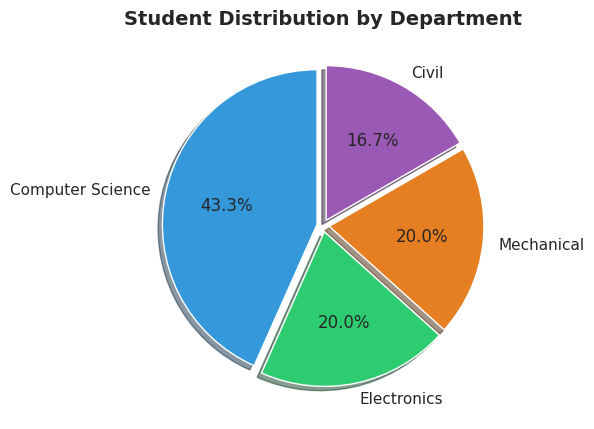

In [29]:

fig, ax = plt.subplots(figsize=(6, 6))
dept_counts = df_viz['department'].value_counts()
ax.pie(dept_counts, labels=dept_counts.index, autopct='%1.1f%%',
       colors=['#3498db','#2ecc71','#e67e22','#9b59b6'],
       startangle=90, explode=[0.04]*len(dept_counts), shadow=True)
ax.set_title('Student Distribution by Department', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

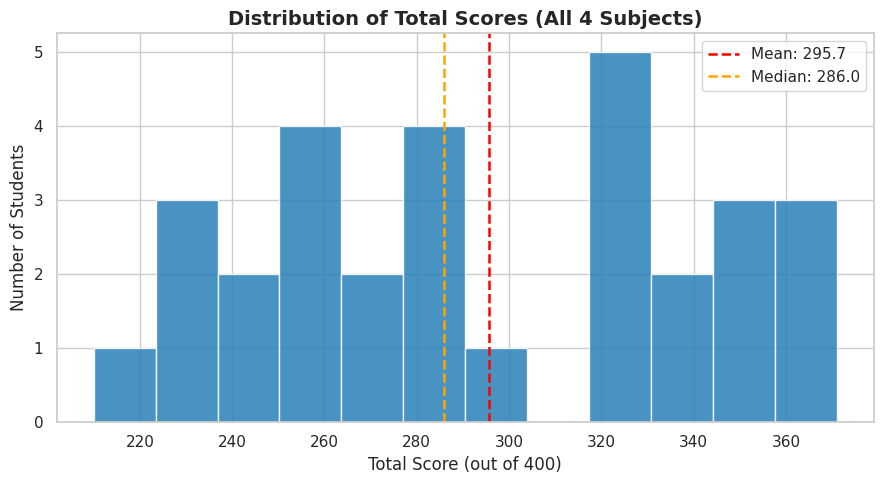

In [30]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_viz['Total_Score'], bins=12, color='#2980b9', edgecolor='white', alpha=0.85)
ax.axvline(df_viz['Total_Score'].mean(), color='red', linestyle='--', linewidth=1.8,
           label=f"Mean: {df_viz['Total_Score'].mean():.1f}")
ax.axvline(df_viz['Total_Score'].median(), color='orange', linestyle='--', linewidth=1.8,
           label=f"Median: {df_viz['Total_Score'].median():.1f}")
ax.set_title('Distribution of Total Scores (All 4 Subjects)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Score (out of 400)')
ax.set_ylabel('Number of Students')
ax.legend()
plt.tight_layout()
plt.show()

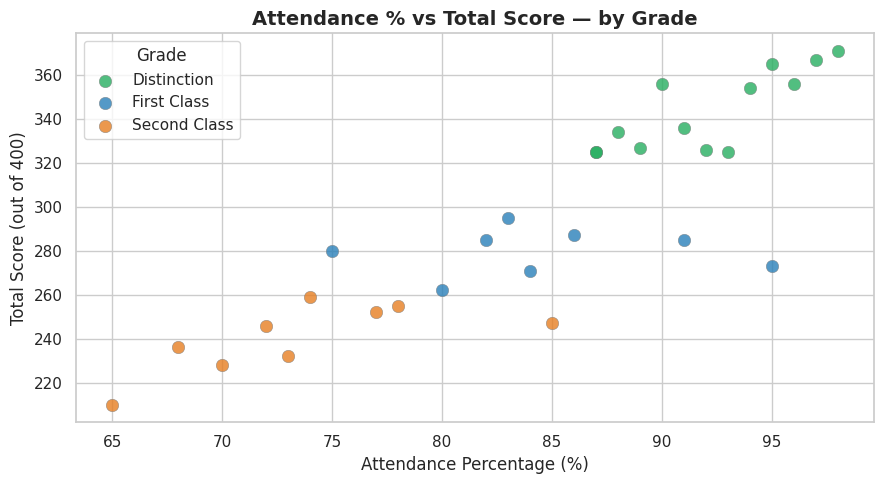

In [31]:

fig, ax = plt.subplots(figsize=(9, 5))
grade_colours = {'Distinction':'#27ae60','First Class':'#2980b9',
                 'Second Class':'#e67e22','Pass':'#e74c3c'}
for grade, grp in df_viz.groupby('Grade'):
    ax.scatter(grp['attendance_percentage'], grp['Total_Score'],
               label=grade, color=grade_colours.get(str(grade), 'grey'),
               s=80, alpha=0.8, edgecolors='grey', linewidth=0.4)
ax.set_title('Attendance % vs Total Score — by Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Attendance Percentage (%)')
ax.set_ylabel('Total Score (out of 400)')
ax.legend(title='Grade')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_ml = pd.read_csv('student_etl_output.csv')

le = LabelEncoder()
df_ml['Gender_Enc'] = le.fit_transform(df_ml['gender'])
df_ml['Dept_Enc']   = le.fit_transform(df_ml['department'])
le.fit(df_ml['Grade'].astype(str))
df_ml['Grade_Enc']  = le.transform(df_ml['Grade'].astype(str))
grade_classes = le.classes_
print('Grade labels:', list(enumerate(grade_classes)))

features = ['math_score','science_score','english_score',
            'programming_score','attendance_percentage','Gender_Enc','Dept_Enc','age']
X = df_ml[features]
y = df_ml['Grade_Enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Grade labels: [(0, 'Distinction'), (1, 'First Class'), (2, 'Second Class')]
Train: 24 | Test: 6


In [33]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=grade_classes))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

 Distinction       1.00      1.00      1.00         3
 First Class       1.00      1.00      1.00         1
Second Class       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



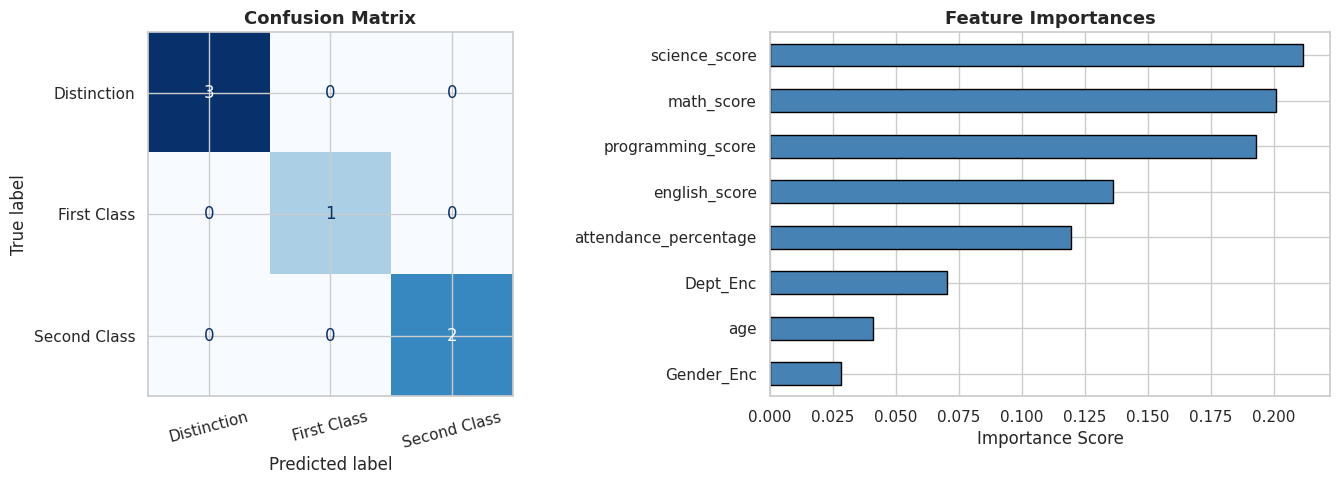

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=grade_classes).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

pd.Series(model.feature_importances_, index=features).sort_values(ascending=True) \
  .plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Feature Importances', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()